# EPI readout corrections

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/epi.ipynb)

`estimate_epi_phase`, `correct_lines` and `epi_ramp_operator`: removing the
Nyquist ghost an alternating readout leaves, and putting ramp-sampled data on
the grid.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[torch]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image

## The Nyquist ghost

An EPI train reads alternate lines in opposite directions, and reversing a
readout does not reverse the delays it was played through. So a line read
backwards carries a phase its forward neighbours do not, and a phase that
alternates with every line puts a copy of the object at half the field of
view.

Below, a delay is impressed on the train: forward lines carry
`+(a*x + b)` in hybrid space and reversed lines carry `-(a*x + b)`.

In [3]:
n = 128
image = phantom(n).astype(complex)
hybrid = mru.ifftc(mru.fftc(image), axes=-1)  # (ky, x)

readout = np.linspace(-1.0, 1.0, n)
slope, offset = 0.6, 0.25

train = []
for ky in range(n):
    backwards = ky % 2 == 1
    sign = -1.0 if backwards else 1.0
    row = hybrid[ky] * np.exp(1j * sign * (slope * readout + offset))
    line = mru.fftc(row[None], axes=-1)  # (coils, samples)
    # A reversed line is stored in the order it was digitised.
    train.append((line[:, ::-1] if backwards else line, backwards))

print(f"{len(train)} lines, {sum(backwards for _, backwards in train)} of them reversed")

128 lines, 64 of them reversed


## The navigator measures the phase directly

Three blip-nulled lines of alternating polarity see the same object, so the
phase difference between the middle one and its neighbours is the odd/even
phase and nothing else. The reversed navigator line is handed over already
flipped back into readout order, which is where a real client flips it too.

In [4]:
centre = hybrid[n // 2]
forward = mru.fftc((centre * np.exp(1j * (slope * readout + offset)))[None], axes=-1)
backward = mru.fftc((centre * np.exp(-1j * (slope * readout + offset)))[None], axes=-1)

fit = mru.estimate_epi_phase([forward, backward, forward])
print(f"fit          {fit.round(3)}")
print(f"impressed    [{2 * offset}, {2 * slope}]")

fit          [-12.066   1.2  ]
impressed    [0.5, 1.2]


The slope is recovered exactly. The constant differs by `2*pi`, which is the
branch the unwrap landed on and is the same rotation — a phase is only ever
determined modulo `2*pi`.

The fit is *twice* the impressed phase because the navigator measures the
difference between a forward line and a reversed one, and the correction is
one-sided: the reversed lines are rotated onto the forward ones rather than
both being met in the middle, so the image does not move.

brightest background voxel: 0.614 -> 1.3e-07


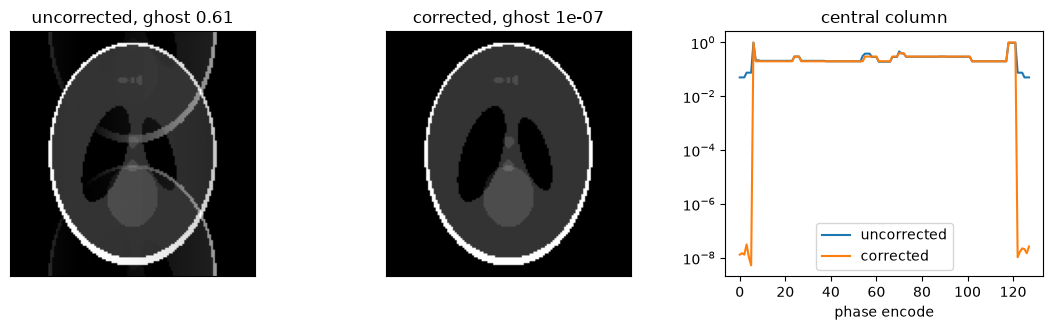

In [5]:
def reconstruct(lines):
    return mru.ifftc(np.concatenate(lines, axis=0))


ghosted = reconstruct(mru.correct_lines(train))  # flipped, not demodulated
corrected = reconstruct(mru.correct_lines(train, fit))

background = np.abs(image) < 1e-6
level = lambda estimate: float(
    np.abs(estimate)[background].max() / np.abs(estimate).max()
)
print(f"brightest background voxel: {level(ghosted):.3f} -> {level(corrected):.1e}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].imshow(np.abs(ghosted), cmap="gray")
axes[0].set_title(f"uncorrected, ghost {level(ghosted):.2f}")
axes[1].imshow(np.abs(corrected), cmap="gray")
axes[1].set_title(f"corrected, ghost {level(corrected):.0e}")
for axis in axes[:2]:
    axis.set_xticks([])
    axis.set_yticks([])
column = n // 2
axes[2].semilogy(np.abs(ghosted)[:, column] + 1e-12, label="uncorrected")
axes[2].semilogy(np.abs(corrected)[:, column] + 1e-12, label="corrected")
axes[2].set_title("central column")
axes[2].set_xlabel("phase encode")
axes[2].legend()
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "epi.png", dpi=110, bbox_inches="tight")

## Ramp sampling

Digitising while the gradient is still moving takes samples that are not on
the grid. Moving them onto it is not an interpolation but a change of basis:
the readout is the transform of an object that occupies `support` pixels and
nothing outside them, so samples taken anywhere determine it everywhere, and
`epi_ramp_operator` is the least-squares inverse of the non-uniform transform
followed by the uniform one.

What makes it exact is that the samples outnumber the pixels they determine —
concretely, that the fast part of the sweep steps less than `1 / support`.
That number is printed below, and it is the condition to check on a real
trajectory.

In [7]:
support, n_ramp = 64, 160
obj = np.zeros(support, dtype=complex)
obj[16:48] = np.linspace(0.3, 1.0, 32) * np.exp(1j * np.linspace(0.0, 2.0, 32))
grid = np.arange(support) - support // 2

# A trapezoid readout gradient; k is its integral, so the ramps are dense and
# the flat top is where the samples are furthest apart.
time = np.linspace(0.0, 1.0, n_ramp)
ramp_fraction = 0.3
gradient = np.clip(np.minimum(time / ramp_fraction, (1 - time) / ramp_fraction), 0, 1)
sampled_k = np.cumsum(gradient)
sampled_k -= sampled_k.mean()
sampled_k = 0.5 * sampled_k / np.abs(sampled_k).max()
uniform_k = np.linspace(-0.5, 0.5, n_ramp, endpoint=False)

encode = lambda positions: np.exp(-2j * np.pi * np.outer(positions, grid)) @ obj
measured, truth = encode(sampled_k), encode(uniform_k)

operator = mru.epi_ramp_operator(sampled_k, uniform_k, support)
resampled = (measured[None] @ operator.T)[0]
linear = np.interp(uniform_k, sampled_k, measured.real) + 1j * np.interp(
    uniform_k, sampled_k, measured.imag
)

error = lambda got: np.linalg.norm(got - truth) / np.linalg.norm(truth)
print(f"widest step x support: {np.diff(sampled_k).max() * support:.2f}  (exact below 1)")
print(f"operator {error(resampled):.1e}   linear interpolation {error(linear):.3f}")

widest step x support: 0.57  (exact below 1)
operator 1.4e-06   linear interpolation 0.032


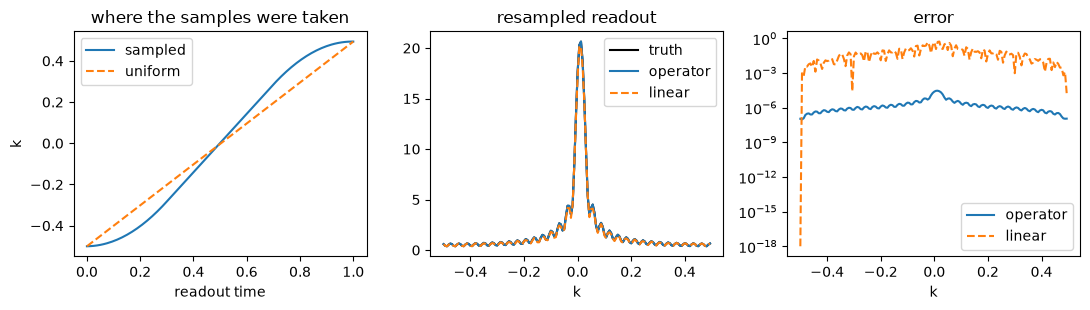

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].plot(time, sampled_k, label="sampled")
axes[0].plot(time, uniform_k, "--", label="uniform")
axes[0].set_title("where the samples were taken")
axes[0].set_xlabel("readout time")
axes[0].set_ylabel("k")
axes[0].legend()

axes[1].plot(uniform_k, np.abs(truth), color="k", label="truth")
axes[1].plot(uniform_k, np.abs(resampled), label="operator")
axes[1].plot(uniform_k, np.abs(linear), "--", label="linear")
axes[1].set_title("resampled readout")
axes[1].set_xlabel("k")
axes[1].legend()

axes[2].semilogy(uniform_k, np.abs(resampled - truth) + 1e-18, label="operator")
axes[2].semilogy(uniform_k, np.abs(linear - truth) + 1e-18, "--", label="linear")
axes[2].set_title("error")
axes[2].set_xlabel("k")
axes[2].legend()
fig.tight_layout()